# Etapa 4 — Ley de Omori como baseline físico

---
> Conjunto de datos obtenido del Servicio Sismológico Nacional, adscrito al Instituto de Geofísica de la Universidad Nacional Autónoma de México

La **Ley de Omori modificada** (Utsu, 1961) describe la tasa de réplicas como:

$$\lambda(t) = \frac{K}{(t + c)^p}$$

donde $t$ es el tiempo en horas desde el sismo principal, $K$ es la productividad, $c$ evita la singularidad en $t=0$ y $p$ controla la velocidad de decaimiento.

El número esperado de réplicas en $[t_1, t_2]$ es:

$$N(t_1, t_2) = \int_{t_1}^{t_2} \lambda(t)\, dt = \frac{K}{1-p}\left[(t_2+c)^{1-p} - (t_1+c)^{1-p}\right] \quad (p \neq 1)$$

Los parámetros se estiman por máxima verosimilitud (Ogata, 1983).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pathlib import Path

In [2]:
mainshocks = pd.read_parquet('mainshocks.parquet')
replicas   = pd.read_parquet('replicas.parquet')

mainshocks['datetime_utc'] = pd.to_datetime(mainshocks['datetime_utc'])
replicas['datetime_utc']   = pd.to_datetime(replicas['datetime_utc'])

CATALOG_END = replicas['datetime_utc'].max()
MAX_T_HORAS = 365 * 24  # cap de 365 días en horas

print(f'Mainshocks: {len(mainshocks)}')
print(f'Réplicas:   {len(replicas):,}')
print(f'Fin del catálogo: {CATALOG_END.date()}')

Mainshocks: 305
Réplicas:   159,614
Fin del catálogo: 2026-06-20


Creamos las funciones de omori que realizarán la estimación de parámetros y el cálculo anterior.

In [3]:
def omori_expected(t1, t2, K, c, p):
    """Número esperado de réplicas en el intervalo [t1, t2] horas."""
    if abs(p - 1.0) < 1e-6:
        return K * np.log((t2 + c) / (t1 + c))
    return K / (1 - p) * ((t2 + c)**(1-p) - (t1 + c)**(1-p))


def fit_omori_mle(times_hr, T_obs):
    """
    Ajuste MLE de la ley de Omori modificada (Ogata, 1983).
    times_hr : tiempos de réplicas sobre Mc en horas (array, valores > 0)
    T_obs    : ventana de observación en horas
    Devuelve dict {K, c, p, log_likelihood} o None si no converge.
    """
    N = len(times_hr)
    if N < 2:
        return None

    def neg_ll(params):
        log_K, log_c, p = params
        if not (0.1 < p < 2.9):
            return 1e10
        K = np.exp(log_K)
        c = np.exp(log_c)
        integral = omori_expected(0, T_obs, K, c, p)
        if integral <= 0:
            return 1e10
        ll = N * log_K - p * np.sum(np.log(times_hr + c)) - integral
        return -ll

    # Estimación inicial
    c0, p0 = 0.1, 1.0
    K0 = max(N * np.log((T_obs + c0) / c0) ** -1, 1e-6)  # para p≈1
    x0 = [np.log(K0), np.log(c0), p0]

    res = minimize(
        neg_ll, x0, method='L-BFGS-B',
        bounds=[(-10, 20), (-6, 4), (0.1, 2.9)],
        options={'maxiter': 2000, 'ftol': 1e-12}
    )

    if res.fun > 1e9:
        return None

    K, c, p = np.exp(res.x[0]), np.exp(res.x[1]), res.x[2]
    return {'K': K, 'c': c, 'p': p, 'log_likelihood': -res.fun}

Realizamos el ajuste por secuencia:

In [4]:
results = []

for _, ms in mainshocks.iterrows():
    ms_id = ms['mainshock_id']

    # Réplicas sobre Mc para este mainshock
    seq = replicas[
        (replicas['mainshock_id'] == ms_id) &
        (replicas['sobre_Mc']) &
        (replicas['dt_horas'] > 0)
    ]['dt_horas'].values

    # Ventana de observación real (limitada por fin del catálogo y cap de 365 días)
    T_obs = min(
        (CATALOG_END - ms['datetime_utc']).total_seconds() / 3600,
        MAX_T_HORAS
    )

    # Ajuste MLE
    fit = fit_omori_mle(seq, T_obs)

    if fit:
        K, c, p = fit['K'], fit['c'], fit['p']
        ll = fit['log_likelihood']
        pred_24h = omori_expected(0, 24, K, c, p)
        pred_48h = omori_expected(0, 48, K, c, p)
    else:
        # Sin suficientes datos: Omori predice 0
        K = c = p = ll = np.nan
        pred_24h = pred_48h = 0.0

    results.append({
        'mainshock_id': ms_id,
        'magnitud': ms['magnitud'],
        'profundidad': ms['profundidad'],
        'categoria_prof': ms['categoria_prof'],
        'estado': ms['estado'],
        'n_replicas_1h': ms['n_replicas_1h'],
        'n_replicas_24h': ms['n_replicas_24h'],   # target real
        'n_replicas_48h': ms['n_replicas_48h'],
        'K': K, 'c': c, 'p': p,
        'log_likelihood': ll,
        'omori_pred_24h': max(pred_24h, 0),
        'omori_pred_48h': max(pred_48h, 0),
        'n_fit': len(seq),
        'T_obs_horas': T_obs,
    })

omori = pd.DataFrame(results)
n_ajustados = omori['p'].notna().sum()
print(f'Secuencias con ajuste MLE exitoso: {n_ajustados} / {len(omori)}')
print(f'Secuencias con predicción = 0 (sin datos suficientes): {len(omori) - n_ajustados}')

Secuencias con ajuste MLE exitoso: 190 / 305
Secuencias con predicción = 0 (sin datos suficientes): 115


Analizamos la distribución de parámetros para identificar el ideal:

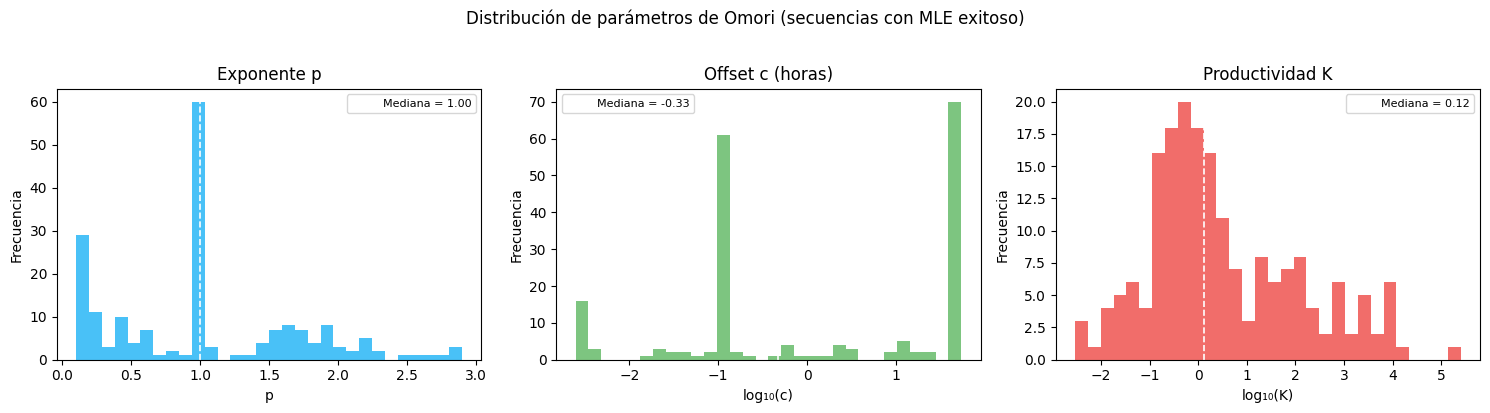


Resumen de parámetros:
             p        c           K
count  190.000  190.000     190.000
mean     1.032   21.084    1891.282
std      0.701   25.809   18263.243
min      0.100    0.002       0.003
25%      0.429    0.100       0.264
50%      1.000    0.473       1.315
75%      1.562   54.598      33.789
max      2.900   54.598  250589.761


In [5]:
validos = omori.dropna(subset=['p'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label, color in zip(
    axes,
    ['p', 'c', 'K'],
    ['Exponente p', 'Offset c (horas)', 'Productividad K'],
    ['#29b6f6', '#66bb6a', '#ef5350']
):
    datos = np.log10(validos[col]) if col in ('c', 'K') else validos[col]
    xlabel = f'log₁₀({col})' if col in ('c', 'K') else col
    ax.hist(datos.dropna(), bins=30, color=color, alpha=0.85)
    ax.axvline(datos.median(), color='white', linestyle='--', linewidth=1.2,
               label=f'Mediana = {datos.median():.2f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frecuencia')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('Distribución de parámetros de Omori (secuencias con MLE exitoso)', y=1.02)
plt.tight_layout()
plt.savefig('omori_params_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nResumen de parámetros:')
print(validos[['p','c','K']].describe().round(3))

Con el resultado anterior, analizamos la correlación de parámetros con características del mainshock:

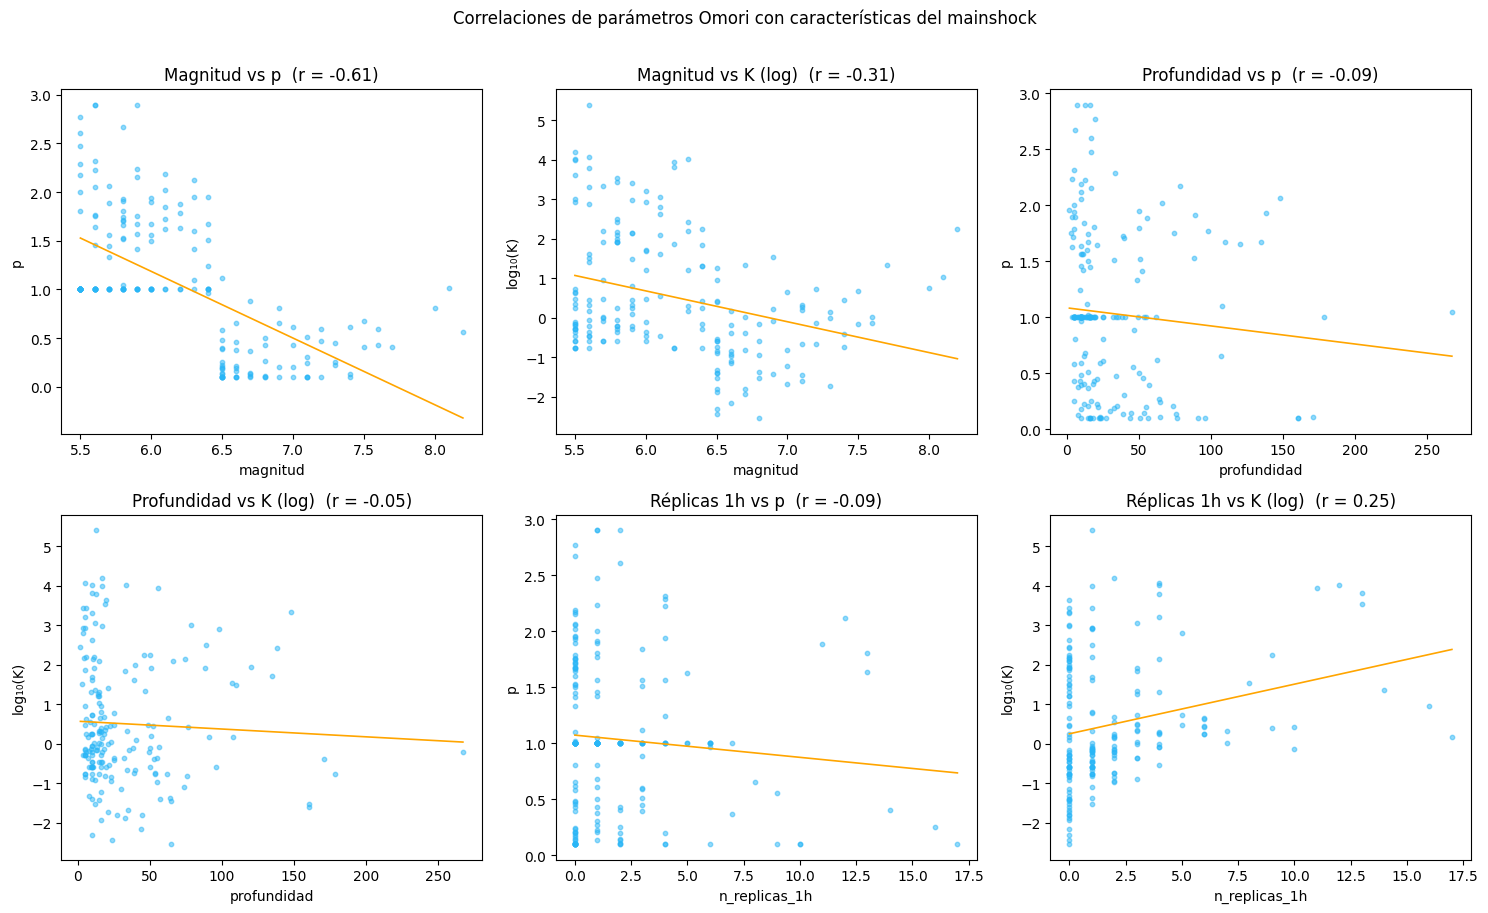

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

pares = [
    ('magnitud', 'p', 'Magnitud vs p'),
    ('magnitud', 'K', 'Magnitud vs K (log)'),
    ('profundidad', 'p', 'Profundidad vs p'),
    ('profundidad', 'K', 'Profundidad vs K (log)'),
    ('n_replicas_1h', 'p', 'Réplicas 1h vs p'),
    ('n_replicas_1h', 'K', 'Réplicas 1h vs K (log)'),
]

for ax, (x_col, y_col, title) in zip(axes.flat, pares):
    sub = validos[[x_col, y_col]].dropna()
    y = np.log10(sub[y_col] + 1e-6) if y_col == 'K' else sub[y_col]
    ax.scatter(sub[x_col], y, s=10, alpha=0.5, color='#29b6f6')
    # Línea de tendencia
    m, b = np.polyfit(sub[x_col], y, 1)
    xs = np.linspace(sub[x_col].min(), sub[x_col].max(), 50)
    ax.plot(xs, m*xs + b, color='orange', linewidth=1.2)
    corr = np.corrcoef(sub[x_col], y)[0, 1]
    ax.set_title(f'{title}  (r = {corr:.2f})')
    ax.set_xlabel(x_col)
    ax.set_ylabel(f'log₁₀(K)' if y_col == 'K' else y_col)

plt.suptitle('Correlaciones de parámetros Omori con características del mainshock', y=1.01)
plt.tight_layout()
plt.savefig('omori_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

El gráfico sugiere que la magnitud es el factor más determinante para moldear el comportamiento del decaimiento temporal de las réplicas (especialmente afectando al parámetro $p$), mientras que la profundidad parece no tener un impacto lineal relevante en los parámetros de Omori calculados.

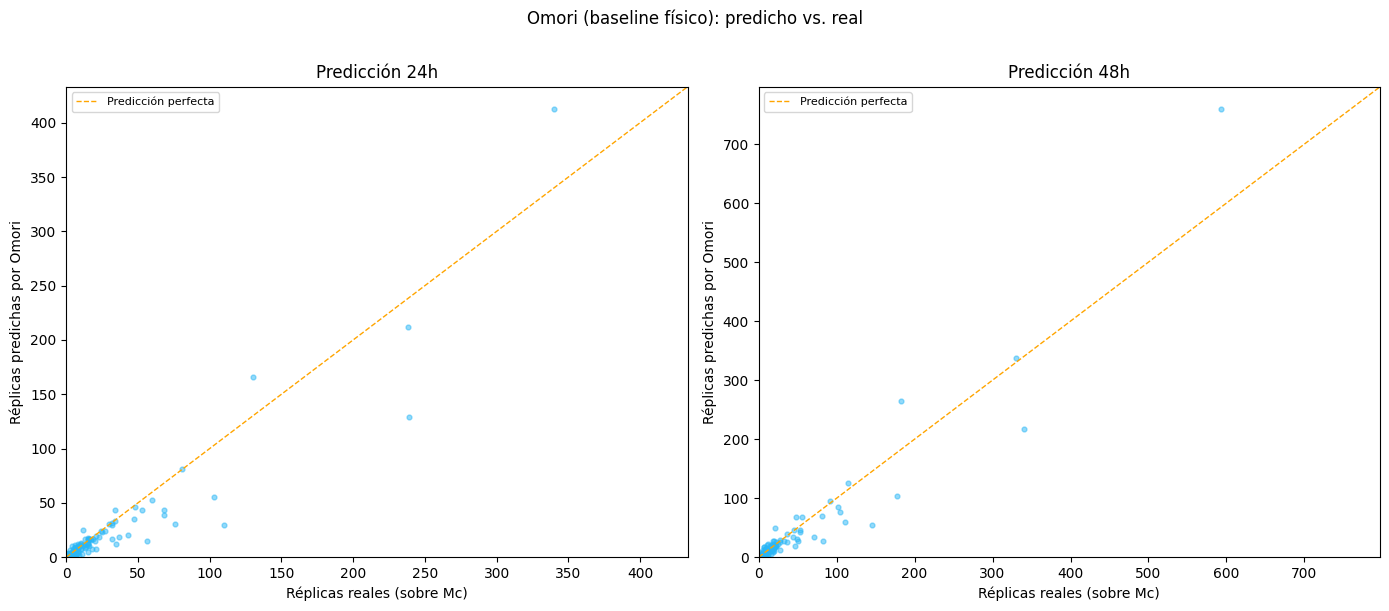

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred_col, real_col, title in zip(
    axes,
    ['omori_pred_24h', 'omori_pred_48h'],
    ['n_replicas_24h', 'n_replicas_48h'],
    ['Predicción 24h', 'Predicción 48h']
):
    real = omori[real_col]
    pred = omori[pred_col]
    lim  = max(real.max(), pred.max()) * 1.05

    ax.scatter(real, pred, s=12, alpha=0.5, color='#29b6f6')
    ax.plot([0, lim], [0, lim], 'orange', linewidth=1, linestyle='--', label='Predicción perfecta')
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel('Réplicas reales (sobre Mc)')
    ax.set_ylabel('Réplicas predichas por Omori')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Omori (baseline físico): predicho vs. real', y=1.01)
plt.tight_layout()
plt.savefig('omori_pred_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

Las siguientes métricas son el umbral a superar en la siguiente etapa usando aprendizaje de máquinas.
Se incluye también la predicción "tonta" (media del corpus) para contextualizar. Cabe destacar que este modelo tiene completo acceso a los datos disponibles, más que *extrapolar*, se trata meramente de una *interpolación* para evaluar la calidad de la información disponible. La comparación justa llegará cuando midamos ambos en las mismas condiciones en la siguiente etapa.

In [8]:
def metricas(real, pred, nombre):
    mae = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred)**2))
    ss_res = np.sum((real - pred)**2)
    ss_tot = np.sum((real - real.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    corr = np.corrcoef(real, pred)[0, 1]
    print(f'  {nombre:<30}  MAE={mae:6.2f}  RMSE={rmse:7.2f}  R²={r2:6.3f}  r={corr:6.3f}')
    return {'nombre': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'corr': corr}

real_24 = omori['n_replicas_24h'].values.astype(float)
real_48 = omori['n_replicas_48h'].values.astype(float)

print('=== MÉTRICAS BASELINE — TARGET: n_replicas_24h ===')
m_tonto = metricas(real_24, np.full_like(real_24, real_24.mean()), 'Predicción media (tonta)')
m_omori = metricas(real_24, omori['omori_pred_24h'].values, 'Omori (baseline físico)')

print('\n=== MÉTRICAS BASELINE — TARGET: n_replicas_48h ===')
metricas(real_48, np.full_like(real_48, real_48.mean()), 'Predicción media (tonta)')
metricas(real_48, omori['omori_pred_48h'].values, 'Omori (baseline físico)')

print(f'\nMedia de n_replicas_24h en corpus: {real_24.mean():.2f}')
print(f'Mediana de n_replicas_24h: {np.median(real_24):.2f}')
print(f'% de mainshocks con 0 réplicas 24h: {(real_24==0).mean()*100:.1f}%')

=== MÉTRICAS BASELINE — TARGET: n_replicas_24h ===
  Predicción media (tonta)        MAE= 13.08  RMSE=  31.23  R²= 0.000  r= 0.000
  Omori (baseline físico)         MAE=  3.14  RMSE=  10.97  R²= 0.877  r= 0.938

=== MÉTRICAS BASELINE — TARGET: n_replicas_48h ===
  Predicción media (tonta)        MAE= 18.93  RMSE=  48.53  R²= 0.000  r=   nan
  Omori (baseline físico)         MAE=  4.39  RMSE=  15.88  R²= 0.893  r= 0.955

Media de n_replicas_24h en corpus: 9.76
Mediana de n_replicas_24h: 1.00
% de mainshocks con 0 réplicas 24h: 38.4%


c:\Users\Unredeemer\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Unredeemer\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Visualicemos ahora las curvas de Omori para secuencias representativas: Las curvas de decaimiento de Omori describen cómo la frecuencia y la intensidad de las réplicas de un terremoto principal disminuyen con el tiempo. El decaimiento sigue una relación de hipérbola rectangular, indicando que la actividad sísmica decae rápidamente al principio y se estabiliza a largo plazo.

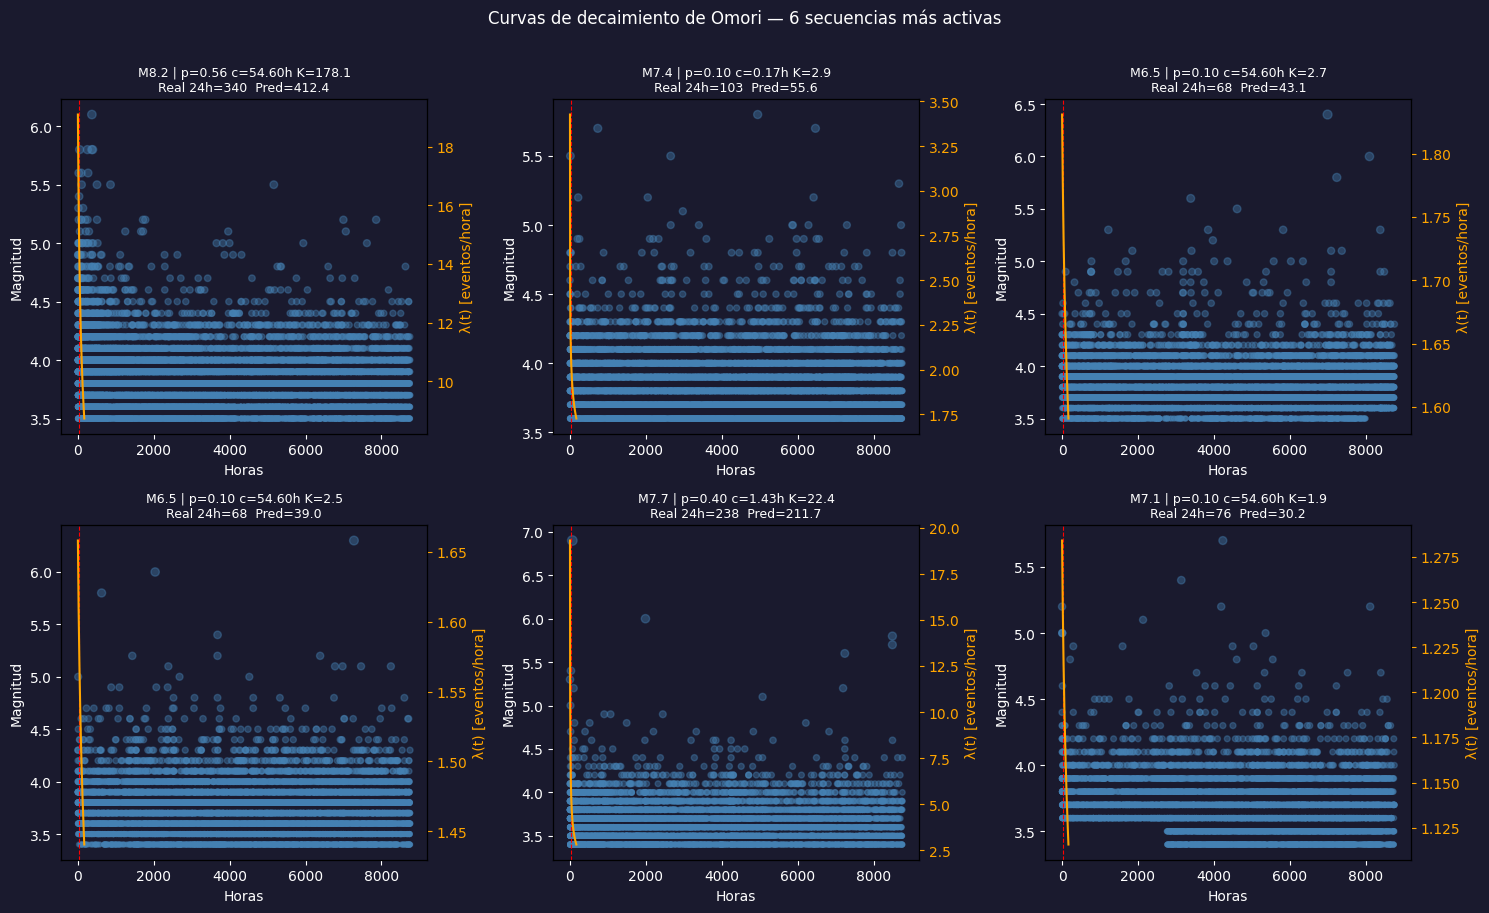

In [9]:
# Seleccionar las 6 secuencias con más réplicas sobre Mc (las mejor ajustadas)
top6 = omori.dropna(subset=['p']).nlargest(6, 'n_fit')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
t_plot = np.linspace(0.01, 24*7, 500)  # 7 días en horas

for ax, (_, row) in zip(axes.flat, top6.iterrows()):
    ms_id = row['mainshock_id']
    seq   = replicas[
        (replicas['mainshock_id'] == ms_id) &
        (replicas['sobre_Mc']) &
        (replicas['dt_horas'] > 0)
    ]

    # Tasa ajustada
    rate = row['K'] / (t_plot + row['c']) ** row['p']

    ax.scatter(seq['dt_horas'], seq['Magnitud'],
               s=seq['Magnitud']**2, alpha=0.4, color='steelblue', label='Réplicas')

    ax2 = ax.twinx()
    ax2.plot(t_plot, rate, color='orange', linewidth=1.5, label='λ(t) Omori')
    ax2.set_ylabel('λ(t) [eventos/hora]', color='orange')
    ax2.tick_params(axis='y', colors='orange')

    ax.axvline(24, color='red', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Horas')
    ax.set_ylabel('Magnitud')
    ax.set_title(
        f'M{row["magnitud"]:.1f} | p={row["p"]:.2f} c={row["c"]:.2f}h K={row["K"]:.1f}\n'
        f'Real 24h={int(row["n_replicas_24h"])}  Pred={row["omori_pred_24h"]:.1f}',
        fontsize=9
    )
    ax.set_facecolor('#1a1a2e')

fig.patch.set_facecolor('#1a1a2e')
for ax in axes.flat:
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

plt.suptitle('Curvas de decaimiento de Omori — 6 secuencias más activas', color='white', y=1.01)
plt.tight_layout()
plt.savefig('omori_curvas.png', dpi=150, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

In [10]:
omori.to_parquet('omori_params.parquet', index=False)
print(f'omori_params.parquet → {len(omori)} filas  ({Path("omori_params.parquet").stat().st_size/1e6:.2f} MB)')

omori_params.parquet → 305 filas  (0.02 MB)
